In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
data_dir = "../data/chest_xray"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [3]:
train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/train",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print(train_dataset.classes)
print(len(train_dataset))

['NORMAL', 'PNEUMONIA']
5216


In [4]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels)

torch.Size([8, 1, 224, 224])
tensor([0, 1, 1, 1, 1, 1, 1, 0])


In [5]:
from collections import Counter

class_counts = Counter(train_dataset.targets)

for class_index, count in class_counts.items():
    print(train_dataset.classes[class_index], count)

NORMAL 1341
PNEUMONIA 3875


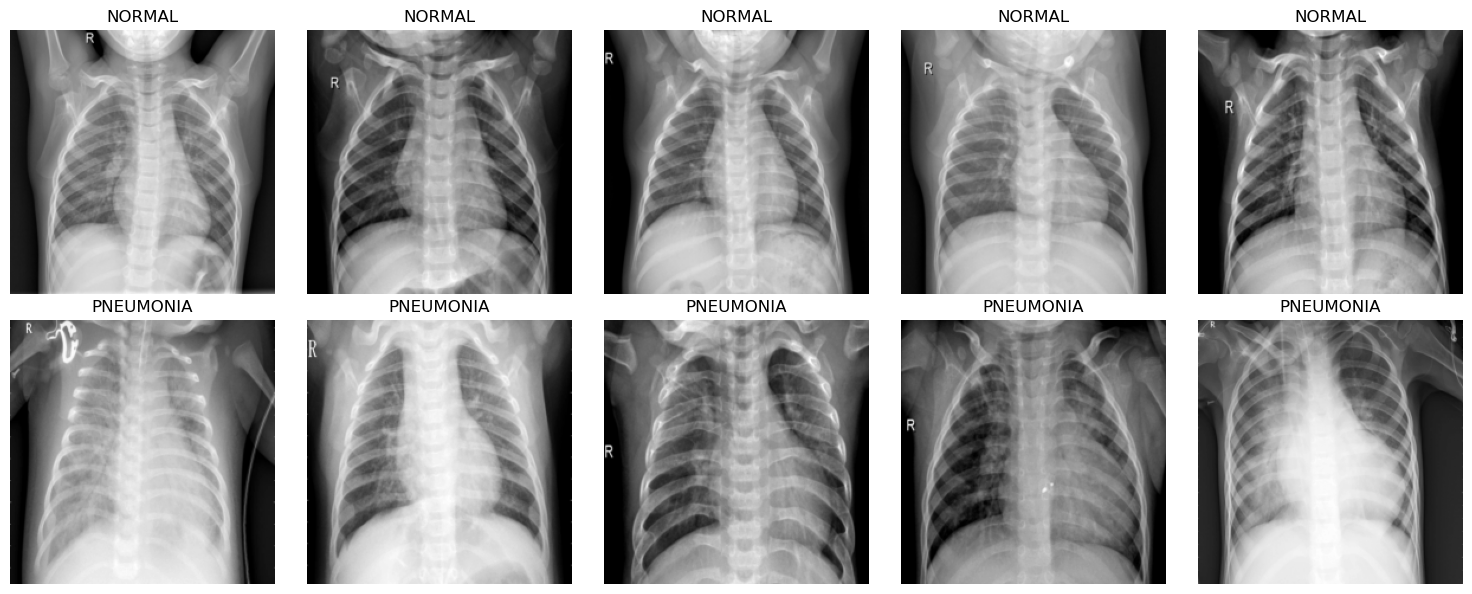

In [6]:
normal_indices = [i for i, label in enumerate(train_dataset.targets) if train_dataset.classes[label] == "NORMAL"]
pneumonia_indices = [i for i, label in enumerate(train_dataset.targets) if train_dataset.classes[label] == "PNEUMONIA"]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, indices in enumerate([normal_indices, pneumonia_indices]):
    for col in range(5):
        image, label = train_dataset[indices[col]]
        axes[row, col].imshow(image.squeeze(), cmap="gray")
        axes[row, col].set_title(train_dataset.classes[label])
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()